# 📌 1. Project Overview & Objectives

`The Challenge`

Mohit-Trust Bank currently uses a manual loan verification process that is slow, inconsistent, and prone to error, resulting in lost business (rejecting good customers) and financial losses (approving high-risk customers).

`The Solution`

To build an intelligent, ML-powered loan approval system using historical customer data. The system will automatically analyze applicant details to predict whether a loan should be Approved or Rejected, ensuring faster, unbiased, and more accurate decision-making before final human review.


In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mohitrai007/loan-approval/loan_approval_data.csv')

# 🔎 2. Data Loading & Inspection 

In [3]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [4]:
df['Employment_Status'].unique()

array(['Salaried', 'Self-employed', 'Contract', 'Unemployed', nan],
      dtype=object)

In [5]:
column = df.columns
print(len(column))
print(column)
df.info()

20
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existin

# 📊 3. Data Type Description & Classification

---

###  Identification & Demographics
* **`Applicant_ID`**
  * **Description:** Unique identifier for each applicant
  * **Data Type:** Categorical - Nominal 
* **`Gender`**
  * **Description:** Male / Female
  * **Data Type:** Categorical - Nominal
* **`Age`**
  * **Description:** Applicant age
  * **Data Type:** Numerical - Continuous
* **`Marital_Status`**
  * **Description:** Married / Single
  * **Data Type:** Categorical - Nominal
* **`Dependents`**
  * **Description:** Number of dependents
  * **Data Type:** Numerical - Discrete

---

###  Employment & Income
* **`Employment_Status`**
  * **Description:** Salaried / Self-Employed / Business
  * **Data Type:** Categorical - Nominal
* **`Education_Level`**
  * **Description:** Undergraduate / Graduate / Postgraduate
  * **Data Type:** Categorical - Ordinal
* **`Employer_Category`**
  * **Description:** Govt / Private / Self
  * **Data Type:** Categorical - Nominal
* **`Applicant_Income`**
  * **Description:** Monthly income of applicant
  * **Data Type:** Numerical - Continuous
* **`Coapplicant_Income`**
  * **Description:** Monthly income of co-applicant
  * **Data Type:** Numerical - Continuous

---

###  Financial History & Metrics
* **`Credit_Score`**
  * **Description:** Credit bureau score
  * **Data Type:** Numerical - Discrete 
* **`Existing_Loans`**
  * **Description:** Number of already running loans
  * **Data Type:** Numerical - Discrete
* **`DTI_Ratio`**
  * **Description:** Debt-to-Income ratio
  * **Data Type:** Numerical - Continuous
* **`Savings`**
  * **Description:** Savings balance
  * **Data Type:** Numerical - Continuous

---

###  Loan & Property Details
* **`Loan_Amount`**
  * **Description:** Loan amount requested
  * **Data Type:** Numerical - Continuous
* **`Loan_Term`**
  * **Description:** Loan duration (months)
  * **Data Type:** Numerical - Discrete
* **`Loan_Purpose`**
  * **Description:** Home / Education / Personal / Business
  * **Data Type:** Categorical - Nominal
* **`Collateral_Value`**
  * **Description:** Value of collateral provided
  * **Data Type:** Numerical - Continuous
* **`Property_Area`**
  * **Description:** Urban / Semi-Urban / Rural
  * **Data Type:** Categorical - Nominal

---

### 🎯 Target Variable
* **`Loan_Approved`**
  * **Description:** 1 = Approved, 0 = Rejected
  * **Data Type:** Categorical - Nominal


# ⚠️ 4. Handling Missing data

In [6]:
# Percentage of Missing data
print(df.shape)
# 1000 Rows and 20 Columns
df.isnull().sum()  # 5% data is missing

(1000, 20)


Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

<Axes: xlabel='Applicant_Income', ylabel='Count'>

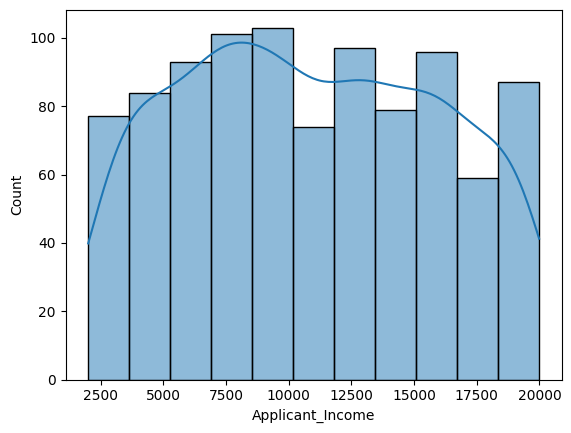

In [7]:
# Distribution of data
sns.histplot(df['Applicant_Income'], kde = True)

In [8]:
# Measure skewness
print(df["Applicant_Income"].skew())

0.07250615913638075


| Skewness | Interpretation    |
| -------- | ----------------- |
| ≈ 0      | Nearly symmetric  |
| 0.5 to 1 | Moderately skewed |
| > 1      | Highly skewed     |

0.0725 falls perfectly into the approx 0 category (Nearly symmetric)


<Axes: >

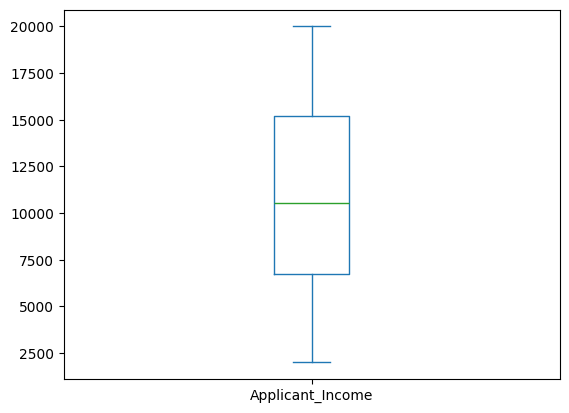

In [9]:
# Checking for outliers

df['Applicant_Income'].plot(kind = 'box')

In [10]:
num_cols = df.select_dtypes(include = "number").columns
cat_cols = df.select_dtypes(include = 'object').columns
# num_cols
print(df[num_cols].describe())

       Applicant_ID  Applicant_Income  Coapplicant_Income         Age  \
count    950.000000        950.000000          950.000000  950.000000   
mean     501.220000      10852.571579         5082.455789   39.971579   
std      289.608451       5061.632859         2943.161570   11.139797   
min        1.000000       2009.000000            1.000000   21.000000   
25%      250.250000       6730.750000         2472.750000   30.250000   
50%      499.500000      10548.000000         5205.500000   40.000000   
75%      752.750000      15190.000000         7620.750000   49.000000   
max     1000.000000      19988.000000         9996.000000   59.000000   

       Dependents  Credit_Score  Existing_Loans   DTI_Ratio       Savings  \
count  950.000000    950.000000      950.000000  950.000000    950.000000   
mean     1.474737    676.033684        1.950526    0.347263   9940.452632   
std      1.105067     71.346015        1.406246    0.144341   5860.736885   
min      0.000000    550.000000   

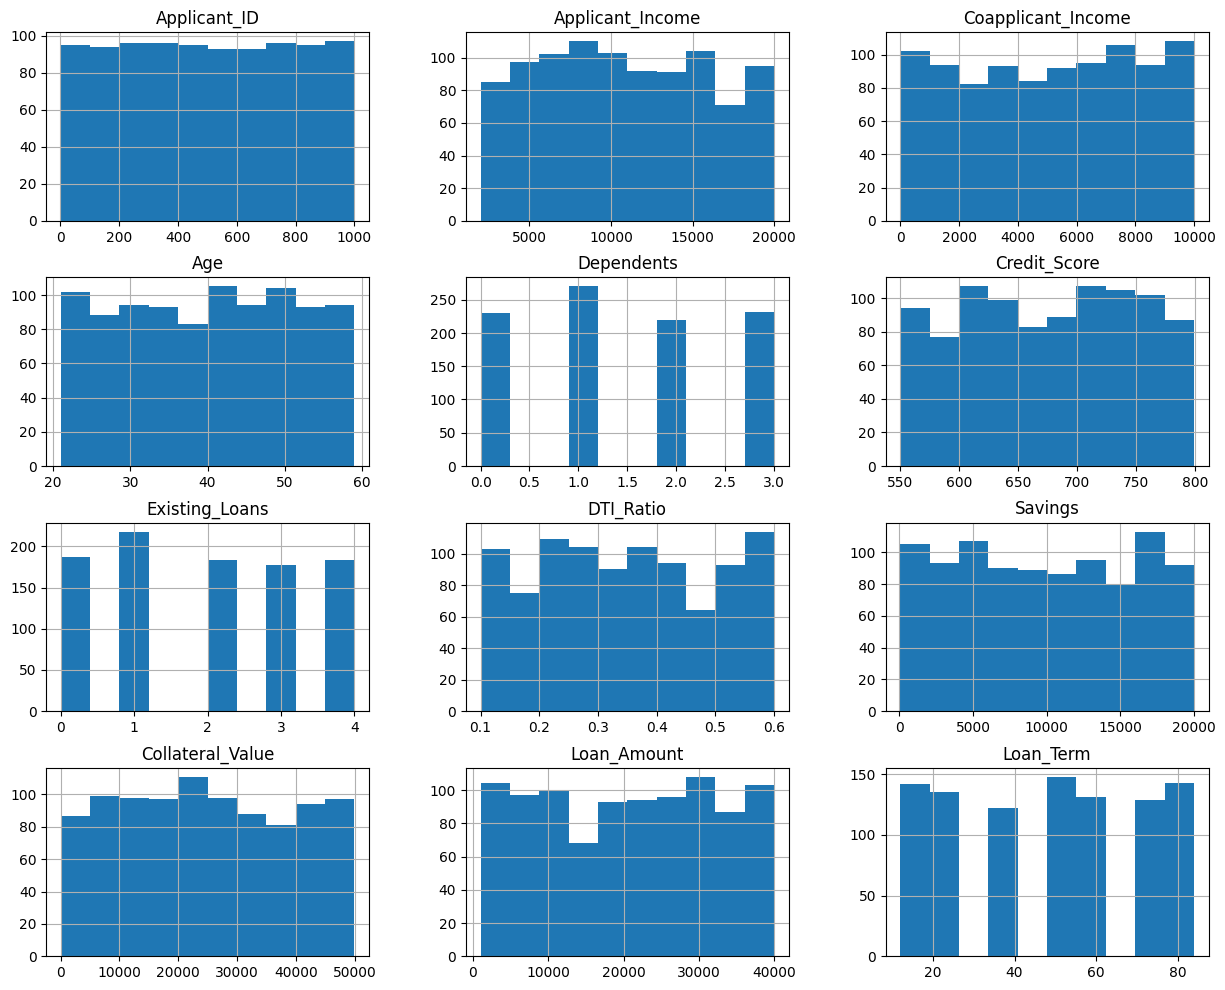

In [11]:
df[num_cols].hist(figsize = (15,12))
plt.show()

In [12]:
df[num_cols].skew()

Applicant_ID          0.001479
Applicant_Income      0.072506
Coapplicant_Income   -0.051148
Age                  -0.020688
Dependents            0.066393
Credit_Score         -0.058889
Existing_Loans        0.081129
DTI_Ratio             0.055658
Savings               0.010542
Collateral_Value      0.064271
Loan_Amount          -0.025619
Loan_Term            -0.001536
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

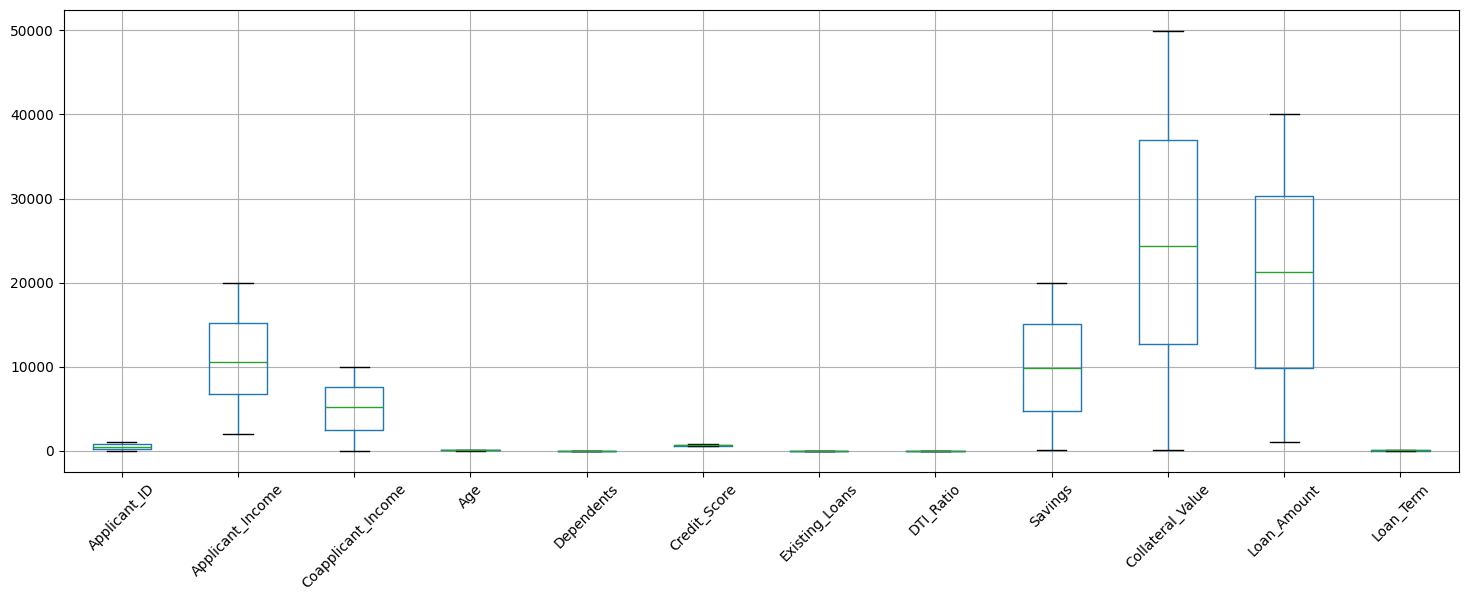

In [13]:
df[num_cols].boxplot(figsize = (18,6))
plt.xticks(rotation = 45)
plt.show

***SUMMARY***

✅ Skew values all within ±0.5 → symmetric distribution

✅ No outliers confirmed by boxplot

✅ Therefore → mean is the right imputation strategy

✅ Data seems normally distributed as we can see in histogram chart.

In [14]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy = 'most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [15]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# 🔎 5. EDA - Exploratory Data Analysis

In [16]:
cat_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

<Axes: xlabel='Employment_Status'>

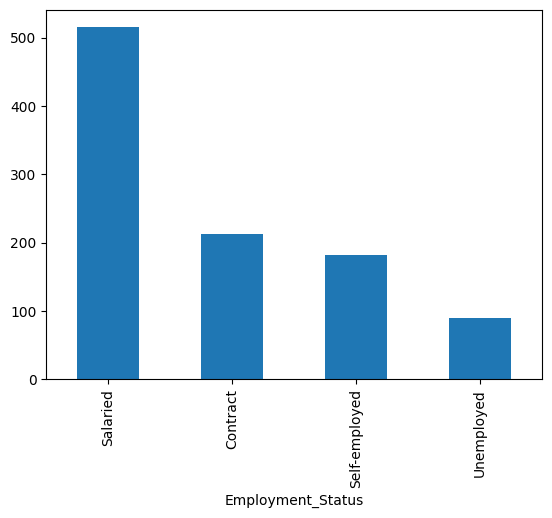

In [17]:
df['Employment_Status'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

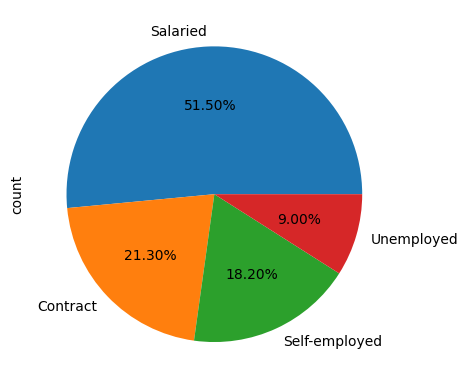

In [18]:
df['Employment_Status'].value_counts().plot(kind = 'pie', autopct = '%1.2f%%')